In [ ]:
# 1. Import the library
from inference_sdk import InferenceHTTPClient

# 2. Connect to your workspace
client = InferenceHTTPClient(
  api_url="https://serverless.roboflow.com",
  api_key="R1zODk2Ja9JHBabfRASg"
)

# 3. Run your workflow on an image
result = client.run_workflow(
  workspace_name="fabiki4429-acoxs-com",
  workflow_id="general-segmentation-api-2",
  images={
    "image": "left-profile.png"  # Path to your image file
  },
  parameters={
    "classes": "ear"
  },
  use_cache=True  # cache workflow definition for 15 minutes
)

# 4. Get your results
print(result)

In [9]:
# 1. Import the library
from inference_sdk import InferenceHTTPClient

# 2. Connect to your workspace
client = InferenceHTTPClient(
  api_url="https://serverless.roboflow.com",
  api_key="R1zODk2Ja9JHBabfRASg"
)

# 3. Run your workflow on an image
result_lower = client.run_workflow(
  workspace_name="fabiki4429-acoxs-com",
  workflow_id="general-segmentation-api-2",
  images={
    "image": "left-profile.png"  # Path to your image file
  },
  parameters={
    "classes": "lower_ear"
  },
  use_cache=True  # cache workflow definition for 15 minutes
)

# 4. Get your results
# print(result)

In [8]:
result[0]['predictions']

{'image': {'width': 1500, 'height': 2000},
 'predictions': [{'width': 309.0,
   'height': 452.0,
   'x': 1151.5,
   'y': 988.0,
   'confidence': 0.93359375,
   'class_id': 0,
   'points': [{'x': 1160.0, 'y': 762.0},
    {'x': 1159.0, 'y': 763.0},
    {'x': 1154.0, 'y': 763.0},
    {'x': 1153.0, 'y': 764.0},
    {'x': 1151.0, 'y': 764.0},
    {'x': 1150.0, 'y': 765.0},
    {'x': 1146.0, 'y': 765.0},
    {'x': 1145.0, 'y': 766.0},
    {'x': 1140.0, 'y': 766.0},
    {'x': 1139.0, 'y': 767.0},
    {'x': 1136.0, 'y': 767.0},
    {'x': 1135.0, 'y': 768.0},
    {'x': 1133.0, 'y': 768.0},
    {'x': 1132.0, 'y': 769.0},
    {'x': 1131.0, 'y': 769.0},
    {'x': 1130.0, 'y': 770.0},
    {'x': 1128.0, 'y': 770.0},
    {'x': 1127.0, 'y': 771.0},
    {'x': 1126.0, 'y': 771.0},
    {'x': 1125.0, 'y': 772.0},
    {'x': 1123.0, 'y': 772.0},
    {'x': 1122.0, 'y': 773.0},
    {'x': 1121.0, 'y': 773.0},
    {'x': 1120.0, 'y': 774.0},
    {'x': 1118.0, 'y': 774.0},
    {'x': 1116.0, 'y': 776.0},
    {'x':

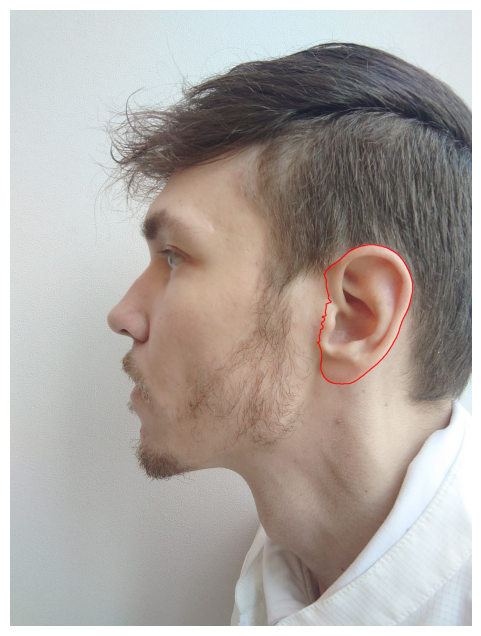

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("left-profile.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get first prediction
prediction = result[0]['predictions']['predictions'][0]

# Convert points to numpy array
points = np.array(
    [[p["x"], p["y"]] for p in prediction["points"]],
    dtype=np.int32
)

# Draw polygon
cv2.polylines(
    image,
    [points],
    isClosed=True,
    color=(255, 0, 0),   # Red
    thickness=2
)

plt.figure(figsize=(6,8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [45]:
plt.imshow(image)
plt.axis("off")
plt.savefig("ear_measurement-1.png", dpi=300, bbox_inches="tight")
plt.close()

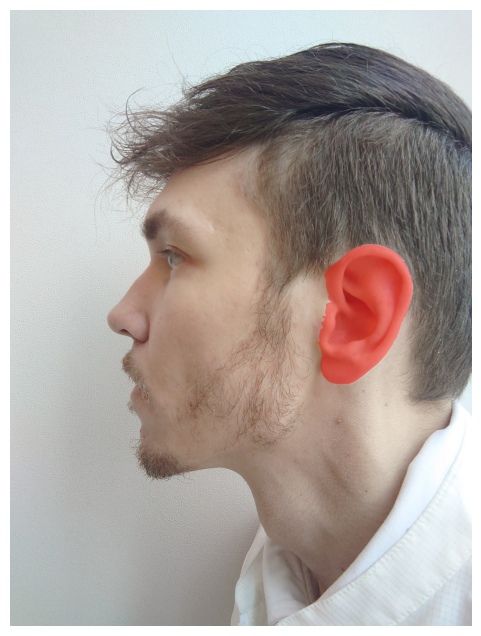

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("left-profile.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

prediction = result[0]['predictions']['predictions'][0]

points = np.array(
    [[p["x"], p["y"]] for p in prediction["points"]],
    np.int32
)

overlay = image.copy()

# Fill polygon
cv2.fillPoly(
    overlay,
    [points],
    color=(255,0,0)
)

alpha = 0.4

image = cv2.addWeighted(
    overlay,
    alpha,
    image,
    1-alpha,
    0
)

plt.figure(figsize=(6,8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [47]:
plt.imshow(image)
plt.axis("off")
plt.savefig("ear_measurement-2.png", dpi=300, bbox_inches="tight")
plt.close()

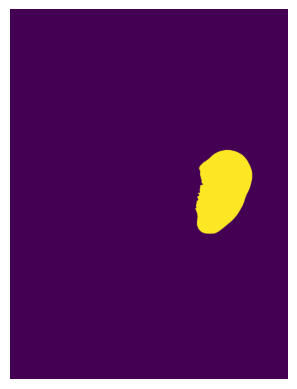

In [36]:
mask = np.zeros(image.shape[:2], dtype=np.uint8)

cv2.fillPoly(mask, [points], 255)

plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

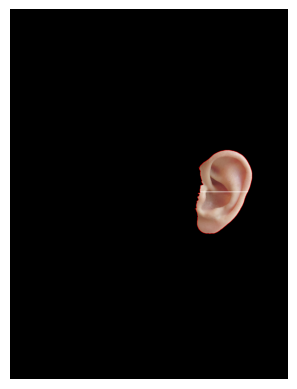

In [57]:
ear = cv2.bitwise_and(image, image, mask=mask)

plt.imshow(ear)
plt.axis("off")
plt.show()


In [59]:
plt.imshow(ear)
plt.axis("off")
plt.savefig("ear_measurement-3.png", dpi=300, bbox_inches="tight")
plt.close()

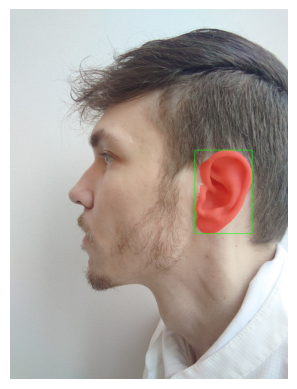

In [53]:
x = prediction["x"]
y = prediction["y"]
w = prediction["width"]
h = prediction["height"]

x1 = int(x - w/2)
y1 = int(y - h/2)
x2 = int(x + w/2)
y2 = int(y + h/2)

cv2.rectangle(image,(x1,y1),(x2,y2),(0,255,0),2)

plt.imshow(image)
plt.axis("off")
plt.show()

In [54]:
plt.imshow(image)
plt.axis("off")
plt.savefig("ear_measurement-4.png", dpi=300, bbox_inches="tight")
plt.close()

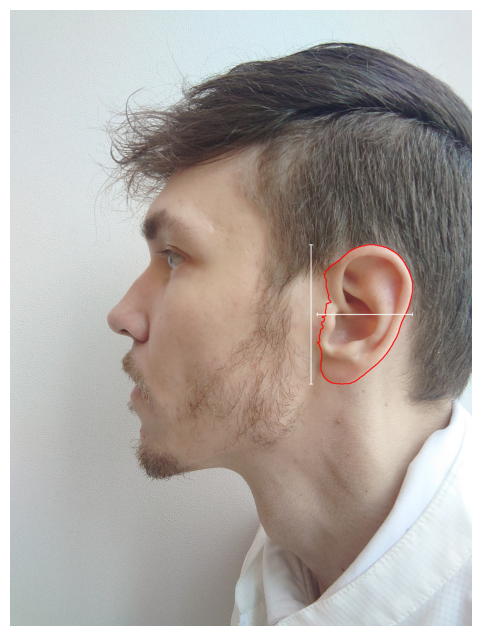

In [55]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("left-profile.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

prediction = result[0]['predictions']['predictions'][0]

# Polygon points
points = np.array([[p["x"], p["y"]] for p in prediction["points"]], dtype=np.int32)

# Bounding box from polygon
x_min = points[:,0].min()
x_max = points[:,0].max()
y_min = points[:,1].min()
y_max = points[:,1].max()

# -------------------------
# Draw polygon (optional)
# -------------------------
cv2.polylines(image, [points], True, (255,0,0), 2)

# =========================
# Vertical measurement line
# =========================

offset = 20   # distance from ear

# Main vertical line
cv2.line(image,
         (x_min-offset, y_min),
         (x_min-offset, y_max),
         (255,255,255),2)

# Top cap
cv2.line(image,
         (x_min-offset-5, y_min),
         (x_min-offset+5, y_min),
         (255,255,255),2)

# Bottom cap
cv2.line(image,
         (x_min-offset-5, y_max),
         (x_min-offset+5, y_max),
         (255,255,255),2)

# =========================
# Horizontal measurement
# =========================

y_mid = int((y_min+y_max)/2)

cv2.line(image,
         (x_min, y_mid),
         (x_max, y_mid),
         (255,255,255),2)

# Left cap
cv2.line(image,
         (x_min, y_mid-5),
         (x_min, y_mid+5),
         (255,255,255),2)

# Right cap
cv2.line(image,
         (x_max, y_mid-5),
         (x_max, y_mid+5),
         (255,255,255),2)

plt.figure(figsize=(6,8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [56]:
plt.imshow(image)
plt.axis("off")
plt.savefig("ear_measurement-5.png", dpi=300, bbox_inches="tight")
plt.close()

In [60]:
prediction = result[0]['predictions']['predictions'][0]

points = np.array(
    [[p["x"], p["y"]] for p in prediction["points"]],
    np.int32
)

In [61]:
x = points[:, 0]
y = points[:, 1]

top = points[np.argmin(y)]
bottom = points[np.argmax(y)]
left = points[np.argmin(x)]
right = points[np.argmax(x)]

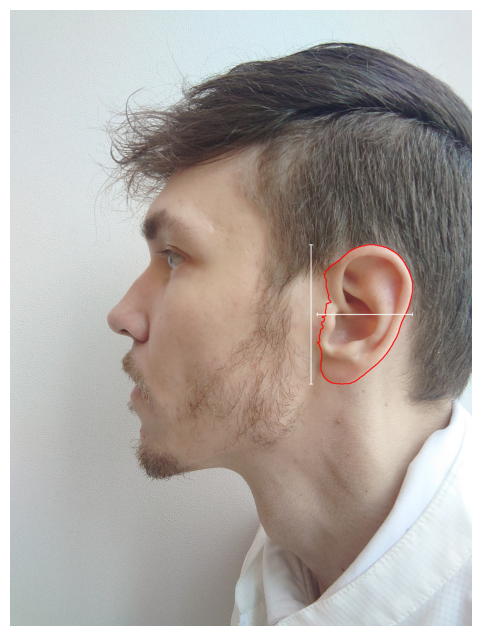

In [63]:
import cv2

img = image.copy()

# Distance of measurement line from ear
offset = 18

# Left measurement line
x_left = int(left[0] - offset)

cv2.line(img,
         (x_left, int(top[1])),
         (x_left, int(bottom[1])),
         (255,255,255),2)

# Top connector
cv2.line(img,
         (x_left, int(top[1])),
         (int(right[0]), int(top[1])),
         (255,255,255),2)

# Bottom connector
cv2.line(img,
         (x_left, int(bottom[1])),
         (int(right[0]), int(bottom[1])),
         (255,255,255),2)

# Right measurement line
cv2.line(img,
         (int(right[0]), int(top[1])),
         (int(right[0]), int(bottom[1])),
         (255,255,255),2)
plt.figure(figsize=(6,8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [78]:
result[0]['predictions']['predictions']

[{'width': 309.0,
  'height': 452.0,
  'x': 1151.5,
  'y': 988.0,
  'confidence': 0.93359375,
  'class_id': 0,
  'points': [{'x': 1160.0, 'y': 762.0},
   {'x': 1159.0, 'y': 763.0},
   {'x': 1154.0, 'y': 763.0},
   {'x': 1153.0, 'y': 764.0},
   {'x': 1151.0, 'y': 764.0},
   {'x': 1150.0, 'y': 765.0},
   {'x': 1146.0, 'y': 765.0},
   {'x': 1145.0, 'y': 766.0},
   {'x': 1140.0, 'y': 766.0},
   {'x': 1139.0, 'y': 767.0},
   {'x': 1136.0, 'y': 767.0},
   {'x': 1135.0, 'y': 768.0},
   {'x': 1133.0, 'y': 768.0},
   {'x': 1132.0, 'y': 769.0},
   {'x': 1131.0, 'y': 769.0},
   {'x': 1130.0, 'y': 770.0},
   {'x': 1128.0, 'y': 770.0},
   {'x': 1127.0, 'y': 771.0},
   {'x': 1126.0, 'y': 771.0},
   {'x': 1125.0, 'y': 772.0},
   {'x': 1123.0, 'y': 772.0},
   {'x': 1122.0, 'y': 773.0},
   {'x': 1121.0, 'y': 773.0},
   {'x': 1120.0, 'y': 774.0},
   {'x': 1118.0, 'y': 774.0},
   {'x': 1116.0, 'y': 776.0},
   {'x': 1115.0, 'y': 776.0},
   {'x': 1114.0, 'y': 777.0},
   {'x': 1112.0, 'y': 777.0},
   {'x': 

In [77]:
pred1 = result[0]["predictions"]['predictions']
for pred in pred1:
    print("Class:", pred["class"])
    print("Confidence:", pred["confidence"])
    
    print("Center:", pred["x"], pred["y"])
    print("Bounding Width:", pred["width"])
    print("Bounding Height:", pred["height"], '\n')

Class: ear
Confidence: 0.93359375
Center: 1151.5 988.0
Bounding Width: 309.0
Bounding Height: 452.0 

Class:  lower_ear
Confidence: 0.59375
Center: 1155.0 987.5
Bounding Width: 302.0
Bounding Height: 453.0 

Class:  upper_ear
Confidence: 0.89453125
Center: 1152.0 987.5
Bounding Width: 310.0
Bounding Height: 453.0 



In [82]:
import numpy as np

points = np.array(
    [[p["x"], p["y"]] for p in pred["points"]],
    dtype=np.int32
)
xmin = points[:,0].min()
xmax = points[:,0].max()

ymin = points[:,1].min()
ymax = points[:,1].max()

print("xmin:", xmin)
print("xmax:", xmax)

print("ymin:", ymin)
print("ymax:", ymax)
ear_height = ymax - ymin

print("Ear Height:", ear_height)

ear_width = xmax - xmin

print("Ear Width:", ear_width)

import cv2

area = cv2.contourArea(points)

print("Area:", area)

xmin: 997
xmax: 1307
ymin: 761
ymax: 1214
Ear Height: 453


In [86]:
"""
ear_calipers.py

Takes the result of your Roboflow "general-segmentation-api-2" workflow
(ear / lower_ear / upper_ear polygons) and generates a cropped,
caliper-style measurement image like a clinical ear-measurement photo:

    - red outline traced from the segmentation polygon
    - a vertical caliper (T-capped) showing ear length (top -> bottom)
    - a horizontal caliper (T-capped) showing ear width at a chosen height

Usage
-----
    from inference_sdk import InferenceHTTPClient
    from ear_calipers import draw_ear_calipers

    client = InferenceHTTPClient(
        api_url="https://serverless.roboflow.com",
        api_key="YOUR_API_KEY",
    )
    result = client.run_workflow(
        workspace_name="fabiki4429-acoxs-com",
        workflow_id="general-segmentation-api-2",
        images={"image": "left-profile.png"},
        parameters={"classes": "ear, lower_ear, upper_ear"},
        use_cache=True,
    )

    draw_ear_calipers(
        image_path="left-profile.png",
        api_result=result,
        output_path="left-profile_calipers.png",
    )

You can also run this file directly:
    python ear_calipers.py left-profile.png result.json output.png
"""

import json
import sys
from PIL import Image, ImageDraw


def _extract_ear_points(api_result, class_name="upper_ear"):
    """
    Pulls the (x, y) polygon points for the requested class out of a
    run_workflow() result. Works whether api_result is the raw list
    returned by the SDK, or a single prediction dict, or a JSON string.
    """
    if isinstance(api_result, str):
        api_result = json.loads(api_result)

    # run_workflow() returns a list with one dict per input image
    if isinstance(api_result, list):
        api_result = api_result[0]

    predictions_block = api_result["predictions"]
    img_meta = predictions_block["image"]           # {"width":.., "height":..}
    predictions = predictions_block["predictions"]   # list of detected objects

    match = next(
        (p for p in predictions if p["class"].strip() == class_name), None
    )
    if match is None:
        available = [p["class"] for p in predictions]
        raise ValueError(
            f"Class '{class_name}' not found in result. Available: {available}"
        )

    points = [(p["x"], p["y"]) for p in match["points"]]
    model_w, model_h = img_meta["width"], img_meta["height"]
    return points, model_w, model_h


def draw_ear_calipers(
    image_path,
    api_result,
    output_path="ear_calipers.png",
    class_name="ear",
    pad_x_frac=0.55,      # left/right padding around ear, as a fraction of ear width
    pad_y_frac=0.20,      # top/bottom padding, as a fraction of ear height
    width_line_height_frac=0.42,  # where (top->bottom) the horizontal caliper sits
    line_color=(255, 255, 255),
    outline_color=(230, 30, 30),
    line_width=3,
    cap_len=14,
):
    """
    Generates a cropped caliper-measurement image and saves it to output_path.
    Returns a dict with the pixel measurements (in the ORIGINAL image's scale).
    """
    # 1. Pull polygon points + the resolution the model actually ran at
    points, model_w, model_h = _extract_ear_points(api_result, class_name)

    # 2. Load the real photo and rescale polygon coords to match its size
    #    (handles the case where the file you're drawing on isn't exactly
    #    the same resolution the API saw)
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    scale_x, scale_y = W / model_w, H / model_h
    pts = [(x * scale_x, y * scale_y) for x, y in points]

    xs, ys = [p[0] for p in pts], [p[1] for p in pts]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    ear_w_px, ear_h_px = max_x - min_x, max_y - min_y

    # 3. Crop tightly around the ear with padding
    pad_x = ear_w_px * pad_x_frac
    pad_y = ear_h_px * pad_y_frac
    crop_box = (
        max(0, min_x - pad_x),
        max(0, min_y - pad_y),
        min(W, max_x + pad_x * 0.6),
        min(H, max_y + pad_y),
    )
    crop_box = tuple(int(v) for v in crop_box)
    cropped = img.crop(crop_box)

    # 4. Shift everything into cropped-image coordinates
    ox, oy = crop_box[0], crop_box[1]
    pts_c = [(x - ox, y - oy) for x, y in pts]
    top, bottom = min_y - oy, max_y - oy
    left, right = min_x - ox, max_x - ox

    draw = ImageDraw.Draw(cropped)

    # 5. Trace the ear outline from the polygon
    draw.line(pts_c + [pts_c[0]], fill=outline_color, width=line_width, joint="curve")

    # 6. Vertical caliper = ear length (top -> bottom), placed just left of the ear
    vx = left - 18
    draw.line([(vx, top), (vx, bottom)], fill=line_color, width=line_width)
    draw.line([(vx - cap_len / 2, top), (vx + cap_len / 2, top)],
               fill=line_color, width=line_width)
    draw.line([(vx - cap_len / 2, bottom), (vx + cap_len / 2, bottom)],
               fill=line_color, width=line_width)

    # 7. Horizontal caliper = ear width, measured at a chosen height band
    hy = top + (bottom - top) * width_line_height_frac
    band = [p for p in pts_c if abs(p[1] - hy) < (bottom - top) * 0.05]
    if band:
        hx_left = min(p[0] for p in band)
        hx_right = max(p[0] for p in band)
    else:
        hx_left, hx_right = left, right

    draw.line([(hx_left, hy), (hx_right, hy)], fill=line_color, width=line_width)
    draw.line([(hx_left, hy - cap_len / 2), (hx_left, hy + cap_len / 2)],
               fill=line_color, width=line_width)
    draw.line([(hx_right, hy - cap_len / 2), (hx_right, hy + cap_len / 2)],
               fill=line_color, width=line_width)

    cropped.save(output_path)

    return {
        "output_path": output_path,
        "ear_height_px": ear_h_px,
        "ear_width_px": ear_w_px,
        "crop_box": crop_box,
    }


# if __name__ == "__main__":
#     # CLI usage: python ear_calipers.py <image_path> <result.json> <output_path>
#     if len(sys.argv) < 3:
#         print("Usage: python ear_calipers.py <image_path> <result.json> [output_path]")
#         sys.exit(1)

#     image_path = sys.argv[1]
#     result_json_path = sys.argv[2]
#     output_path = sys.argv[3] if len(sys.argv) > 3 else "ear_calipers.png"

#     with open(result_json_path) as f:
#         api_result = json.load(f)

measurements = draw_ear_calipers('left-profile.png', result, 'output_path.png')
print(measurements)

{'output_path': 'output_path.png', 'ear_height_px': 452.0, 'ear_width_px': 309.0, 'crop_box': (827, 671, 1407, 1304)}


In [91]:
"""
ear_calipers.py

Takes the result of your Roboflow "general-segmentation-api-2" workflow
(classes: ear, upper_ear, lower_ear) and generates ONE combined image:

    - all 3 class outlines drawn in different colors (with a legend)
    - a vertical caliper (ear length, top -> bottom) from the main "ear" class
    - a horizontal caliper (ear width) from the main "ear" class
    - an on-image analysis panel listing height/width for every class,
      their averages, and the auricular (ear) index = width/height * 100

Usage
-----
    from inference_sdk import InferenceHTTPClient
    from ear_calipers import draw_ear_calipers

    client = InferenceHTTPClient(
        api_url="https://serverless.roboflow.com",
        api_key="YOUR_API_KEY",
    )
    result = client.run_workflow(
        workspace_name="fabiki4429-acoxs-com",
        workflow_id="general-segmentation-api-2",
        images={"image": "left-profile.png"},
        parameters={"classes": "ear, lower_ear, upper_ear"},
        use_cache=True,
    )

    draw_ear_calipers(
        image_path="left-profile.png",
        api_result=result,
        output_path="left-profile_calipers.png",
    )

CLI
---
    python ear_calipers.py left-profile.png result.json output.png
"""

import json
import sys
from PIL import Image, ImageDraw, ImageFont

FONT_PATH_BOLD = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"
FONT_PATH_REG = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"

# Distinct color per class (extend if your model has more classes)
CLASS_COLORS = {
    "ear": (230, 30, 30),          # red
    "upper_ear": (40, 130, 240),   # blue
    "lower_ear": (40, 200, 90),    # green
}
DEFAULT_COLOR = (240, 180, 20)     # amber, for any unlisted class


def _load_all_classes(api_result):
    """Returns {class_name: [(x,y), ...]}, model_w, model_h"""
    if isinstance(api_result, str):
        api_result = json.loads(api_result)
    if isinstance(api_result, list):
        api_result = api_result[0]

    predictions_block = api_result["predictions"]
    img_meta = predictions_block["image"]
    predictions = predictions_block["predictions"]

    classes = {}
    for p in predictions:
        name = p["class"].strip()
        classes[name] = [(pt["x"], pt["y"]) for pt in p["points"]]

    return classes, img_meta["width"], img_meta["height"]


def _bbox(pts):
    xs, ys = [p[0] for p in pts], [p[1] for p in pts]
    return min(xs), min(ys), max(xs), max(ys)


def draw_ear_calipers(
    image_path,
    api_result,
    output_path="ear_calipers.png",
    primary_class="ear",          # class used for the caliper lines & crop
    pad_x_frac=0.55,
    pad_y_frac=0.20,
    width_line_height_frac=0.42,
    line_color=(255, 255, 255),
    line_width=3,
    cap_len=14,
    panel_height=150,             # analysis text panel height (px, before scaling)
):
    """
    Draws outlines for every class returned by the API in one image,
    adds calipers based on `primary_class`, and appends an analysis
    panel with per-class measurements + auricular index.

    Returns a dict of all computed measurements.
    """
    classes, model_w, model_h = _load_all_classes(api_result)
    if primary_class not in classes:
        primary_class = next(iter(classes))  # fall back to first class found

    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    scale_x, scale_y = W / model_w, H / model_h

    # scale every class's points into the real image's pixel space
    scaled = {name: [(x * scale_x, y * scale_y) for x, y in pts]
              for name, pts in classes.items()}

    # crop box driven by the primary class (usually "ear", the full outline)
    min_x, min_y, max_x, max_y = _bbox(scaled[primary_class])
    ear_w_px, ear_h_px = max_x - min_x, max_y - min_y
    pad_x, pad_y = ear_w_px * pad_x_frac, ear_h_px * pad_y_frac
    crop_box = (
        max(0, min_x - pad_x),
        max(0, min_y - pad_y),
        min(W, max_x + pad_x * 0.6),
        min(H, max_y + pad_y),
    )
    crop_box = tuple(int(v) for v in crop_box)
    cropped = img.crop(crop_box)
    ox, oy = crop_box[0], crop_box[1]

    # shift all classes into cropped coordinates
    pts_by_class = {name: [(x - ox, y - oy) for x, y in pts]
                     for name, pts in scaled.items()}

    draw = ImageDraw.Draw(cropped)

    # ---- draw every class outline ----
    for name, pts_c in pts_by_class.items():
        color = CLASS_COLORS.get(name, DEFAULT_COLOR)
        draw.line(pts_c + [pts_c[0]], fill=color, width=2, joint="curve")

    # ---- calipers from the primary class ----
    top = min_y - oy
    bottom = max_y - oy
    left = min_x - ox
    right = max_x - ox

    vx = left - 18
    draw.line([(vx, top), (vx, bottom)], fill=line_color, width=line_width)
    draw.line([(vx - cap_len / 2, top), (vx + cap_len / 2, top)],
               fill=line_color, width=line_width)
    draw.line([(vx - cap_len / 2, bottom), (vx + cap_len / 2, bottom)],
               fill=line_color, width=line_width)

    hy = top + (bottom - top) * width_line_height_frac
    band = [p for p in pts_by_class[primary_class] if abs(p[1] - hy) < (bottom - top) * 0.05]
    if band:
        hx_left, hx_right = min(p[0] for p in band), max(p[0] for p in band)
    else:
        hx_left, hx_right = left, right

    draw.line([(hx_left, hy), (hx_right, hy)], fill=line_color, width=line_width)
    draw.line([(hx_left, hy - cap_len / 2), (hx_left, hy + cap_len / 2)],
               fill=line_color, width=line_width)
    draw.line([(hx_right, hy - cap_len / 2), (hx_right, hy + cap_len / 2)],
               fill=line_color, width=line_width)

    # ---- per-class measurements (in ORIGINAL image pixel scale) ----
    measurements = {}
    for name, pts in scaled.items():
        bx0, by0, bx1, by1 = _bbox(pts)
        h = by1 - by0
        w = bx1 - bx0
        measurements[name] = {
            "height_px": round(h, 1),
            "width_px": round(w, 1),
            "auricular_index": round((w / h) * 100, 1) if h else None,
        }

    avg_h = sum(m["height_px"] for m in measurements.values()) / len(measurements)
    avg_w = sum(m["width_px"] for m in measurements.values()) / len(measurements)
    avg_index = round((avg_w / avg_h) * 100, 1) if avg_h else None

    # ---- build the analysis panel and append it below the image ----
    cw, ch = cropped.size
    panel = Image.new("RGB", (cw, panel_height), (18, 18, 22))
    pdraw = ImageDraw.Draw(panel)

    try:
        font_bold = ImageFont.truetype(FONT_PATH_BOLD, 15)
        font_reg = ImageFont.truetype(FONT_PATH_REG, 13)
    except OSError:
        font_bold = font_reg = ImageFont.load_default()

    pdraw.text((10, 8), "Ear Analysis", font=font_bold, fill=(255, 255, 255))

    y = 30
    for name, m in measurements.items():
        color = CLASS_COLORS.get(name, DEFAULT_COLOR)
        pdraw.rectangle([10, y + 3, 22, y + 15], fill=color)
        label = name.replace("_", " ").title()
        pdraw.text(
            (28, y),
            f"{label}:  H={m['height_px']}px   W={m['width_px']}px   Index={m['auricular_index']}",
            font=font_reg, fill=(230, 230, 230),
        )
        y += 20

    y += 4
    pdraw.line([(10, y), (cw - 10, y)], fill=(80, 80, 85), width=1)
    y += 8
    pdraw.text(
        (10, y),
        f"Average:  H={avg_h:.1f}px   W={avg_w:.1f}px   Auricular Index={avg_index}",
        font=font_bold, fill=(255, 220, 120),
    )

    # ---- stitch cropped ear image + panel together ----
    combined = Image.new("RGB", (cw, ch + panel_height), (18, 18, 22))
    combined.paste(cropped, (0, 0))
    combined.paste(panel, (0, ch))
    combined.save(output_path)

    return {
        "output_path": output_path,
        "per_class": measurements,
        "average": {"height_px": round(avg_h, 1), "width_px": round(avg_w, 1),
                     "auricular_index": avg_index},
        "crop_box": crop_box,
    }


# if __name__ == "__main__":
#     if len(sys.argv) < 3:
#         print("Usage: python ear_calipers.py <image_path> <result.json> [output_path]")
#         sys.exit(1)

#     image_path = sys.argv[1]
#     result_json_path = sys.argv[2]
#     output_path = sys.argv[3] if len(sys.argv) > 3 else "ear_calipers.png"

#     with open(result_json_path) as f:
#         api_result = json.load(f)

measurements = draw_ear_calipers('images.jpg', result_2, 'output_path2.jpg')
print(json.dumps(measurements, indent=2))

print(measurements)

{
  "output_path": "output_path2.jpg",
  "per_class": {
    "ear": {
      "height_px": 94.0,
      "width_px": 51.0,
      "auricular_index": 54.3
    },
    "upper_ear": {
      "height_px": 94.0,
      "width_px": 51.0,
      "auricular_index": 54.3
    }
  },
  "average": {
    "height_px": 94.0,
    "width_px": 51.0,
    "auricular_index": 54.3
  },
  "crop_box": [
    182,
    161,
    278,
    292
  ]
}
{'output_path': 'output_path2.jpg', 'per_class': {'ear': {'height_px': 94.0, 'width_px': 51.0, 'auricular_index': 54.3}, 'upper_ear': {'height_px': 94.0, 'width_px': 51.0, 'auricular_index': 54.3}}, 'average': {'height_px': 94.0, 'width_px': 51.0, 'auricular_index': 54.3}, 'crop_box': (182, 161, 278, 292)}


In [93]:
import json
import math
import sys
from PIL import Image, ImageDraw


def _extract_ear_points(api_result, class_name="ear"):
    """
    Pulls the (x, y) polygon points for the requested class out of a
    run_workflow() result. Works whether api_result is the raw list
    returned by the SDK, or a single prediction dict, or a JSON string.
    """
    if isinstance(api_result, str):
        api_result = json.loads(api_result)

    # run_workflow() returns a list with one dict per input image
    if isinstance(api_result, list):
        api_result = api_result[0]

    predictions_block = api_result["predictions"]
    img_meta = predictions_block["image"]           # {"width":.., "height":..}
    predictions = predictions_block["predictions"]   # list of detected objects

    match = next(
        (p for p in predictions if p["class"].strip() == class_name), None
    )
    if match is None:
        available = [p["class"] for p in predictions]
        raise ValueError(
            f"Class '{class_name}' not found in result. Available: {available}"
        )

    points = [(p["x"], p["y"]) for p in match["points"]]
    model_w, model_h = img_meta["width"], img_meta["height"]
    return points, model_w, model_h


def _draw_capped_line(draw, p1, p2, color, width, cap_len):
    """Draws a line from p1 to p2 with small perpendicular end-cap ticks
    (a caliper look), regardless of the line's angle."""
    draw.line([p1, p2], fill=color, width=width)

    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    length = math.hypot(dx, dy)
    if length == 0:
        return
    ux, uy = dx / length, dy / length      # unit vector along the line
    px, py = -uy, ux                       # perpendicular unit vector
    half = cap_len / 2
    for (cx, cy) in (p1, p2):
        a = (cx - px * half, cy - py * half)
        b = (cx + px * half, cy + py * half)
        draw.line([a, b], fill=color, width=width)


def draw_ear_calipers(
    image_path,
    api_result,
    output_path="ear_calipers.png",
    class_name="ear",
    pad_x_frac=0.55,      # left/right padding around ear, as a fraction of ear width
    pad_y_frac=0.20,      # top/bottom padding, as a fraction of ear height
    width_line_height_frac=0.20,  # where (top->bottom) the horizontal caliper sits
    line_color=(255, 255, 255),
    outline_color=None,   # set to e.g. (230,30,30) if you also want the red outline
    line_width=2,
    cap_len=14,
):
    """
    Generates a cropped caliper-measurement image with THREE measurement
    lines, matching the reference style:

        1. Vertical caliper (outside, left of the ear)  -> overall ear height
        2. Horizontal caliper (near the top of the ear) -> upper ear width
        3. Diagonal caliper (drawn through the ear)      -> true point-to-point
           length between the ear's topmost and bottommost points (ears are
           rarely perfectly vertical, so this is the "true axis" length)

    Saves the annotated crop to output_path and returns the measurements
    (in the ORIGINAL image's pixel scale).
    """
    # 1. Pull polygon points + the resolution the model actually ran at
    points, model_w, model_h = _extract_ear_points(api_result, class_name)

    # 2. Load the real photo and rescale polygon coords to match its size
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    scale_x, scale_y = W / model_w, H / model_h
    pts = [(x * scale_x, y * scale_y) for x, y in points]

    xs, ys = [p[0] for p in pts], [p[1] for p in pts]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    ear_w_px, ear_h_px = max_x - min_x, max_y - min_y

    # 3. Crop tightly around the ear with padding
    pad_x = ear_w_px * pad_x_frac
    pad_y = ear_h_px * pad_y_frac
    crop_box = (
        max(0, min_x - pad_x),
        max(0, min_y - pad_y),
        min(W, max_x + pad_x * 0.6),
        min(H, max_y + pad_y),
    )
    crop_box = tuple(int(v) for v in crop_box)
    cropped = img.crop(crop_box)

    # 4. Shift everything into cropped-image coordinates
    ox, oy = crop_box[0], crop_box[1]
    pts_c = [(x - ox, y - oy) for x, y in pts]
    top, bottom = min_y - oy, max_y - oy
    left, right = min_x - ox, max_x - ox

    draw = ImageDraw.Draw(cropped)

    # (optional) trace the ear outline from the polygon
    if outline_color is not None:
        draw.line(pts_c + [pts_c[0]], fill=outline_color, width=2, joint="curve")

    # 5. Vertical caliper = overall ear height, placed just left of the ear
    vx = left - 18
    _draw_capped_line(draw, (vx, top), (vx, bottom), line_color, line_width, cap_len)

    # 6. Horizontal caliper = width near the TOP of the ear
    hy = top + (bottom - top) * width_line_height_frac
    band = [p for p in pts_c if abs(p[1] - hy) < (bottom - top) * 0.05]
    if band:
        hx_left = min(p[0] for p in band)
        hx_right = max(p[0] for p in band)
    else:
        hx_left, hx_right = left, right
    _draw_capped_line(draw, (hx_left, hy), (hx_right, hy), line_color, line_width, cap_len)

    # 7. Diagonal caliper = true length axis, topmost point -> bottommost point
    #    (drawn through the ear itself, like the reference image)
    top_pt = min(pts_c, key=lambda p: p[1])
    bottom_pt = max(pts_c, key=lambda p: p[1])
    _draw_capped_line(draw, top_pt, bottom_pt, line_color, line_width, cap_len * 0.85)

    cropped.save(output_path)

    diag_len_px = math.hypot(
        (bottom_pt[0] - top_pt[0]) / scale_x if scale_x else 0,
        (bottom_pt[1] - top_pt[1]) / scale_y if scale_y else 0,
    ) * ((scale_x + scale_y) / 2)  # ~ back to original-image pixel scale

    return {
        "output_path": output_path,
        "ear_height_px": ear_h_px,          # vertical bounding-box height
        "ear_width_top_px": hx_right - hx_left,  # width at the top band
        "ear_diagonal_length_px": diag_len_px,   # true top->bottom point distance
        "crop_box": crop_box,
    }


measurements = draw_ear_calipers('images.jpg', result_2, 'output_path-2.jpg')
print(measurements)

{'output_path': 'output_path-2.jpg', 'ear_height_px': 94.0, 'ear_width_top_px': 44.0, 'ear_diagonal_length_px': 95.1892851112981, 'crop_box': (182, 161, 278, 292)}
